### 마법의 돌다리 건너기

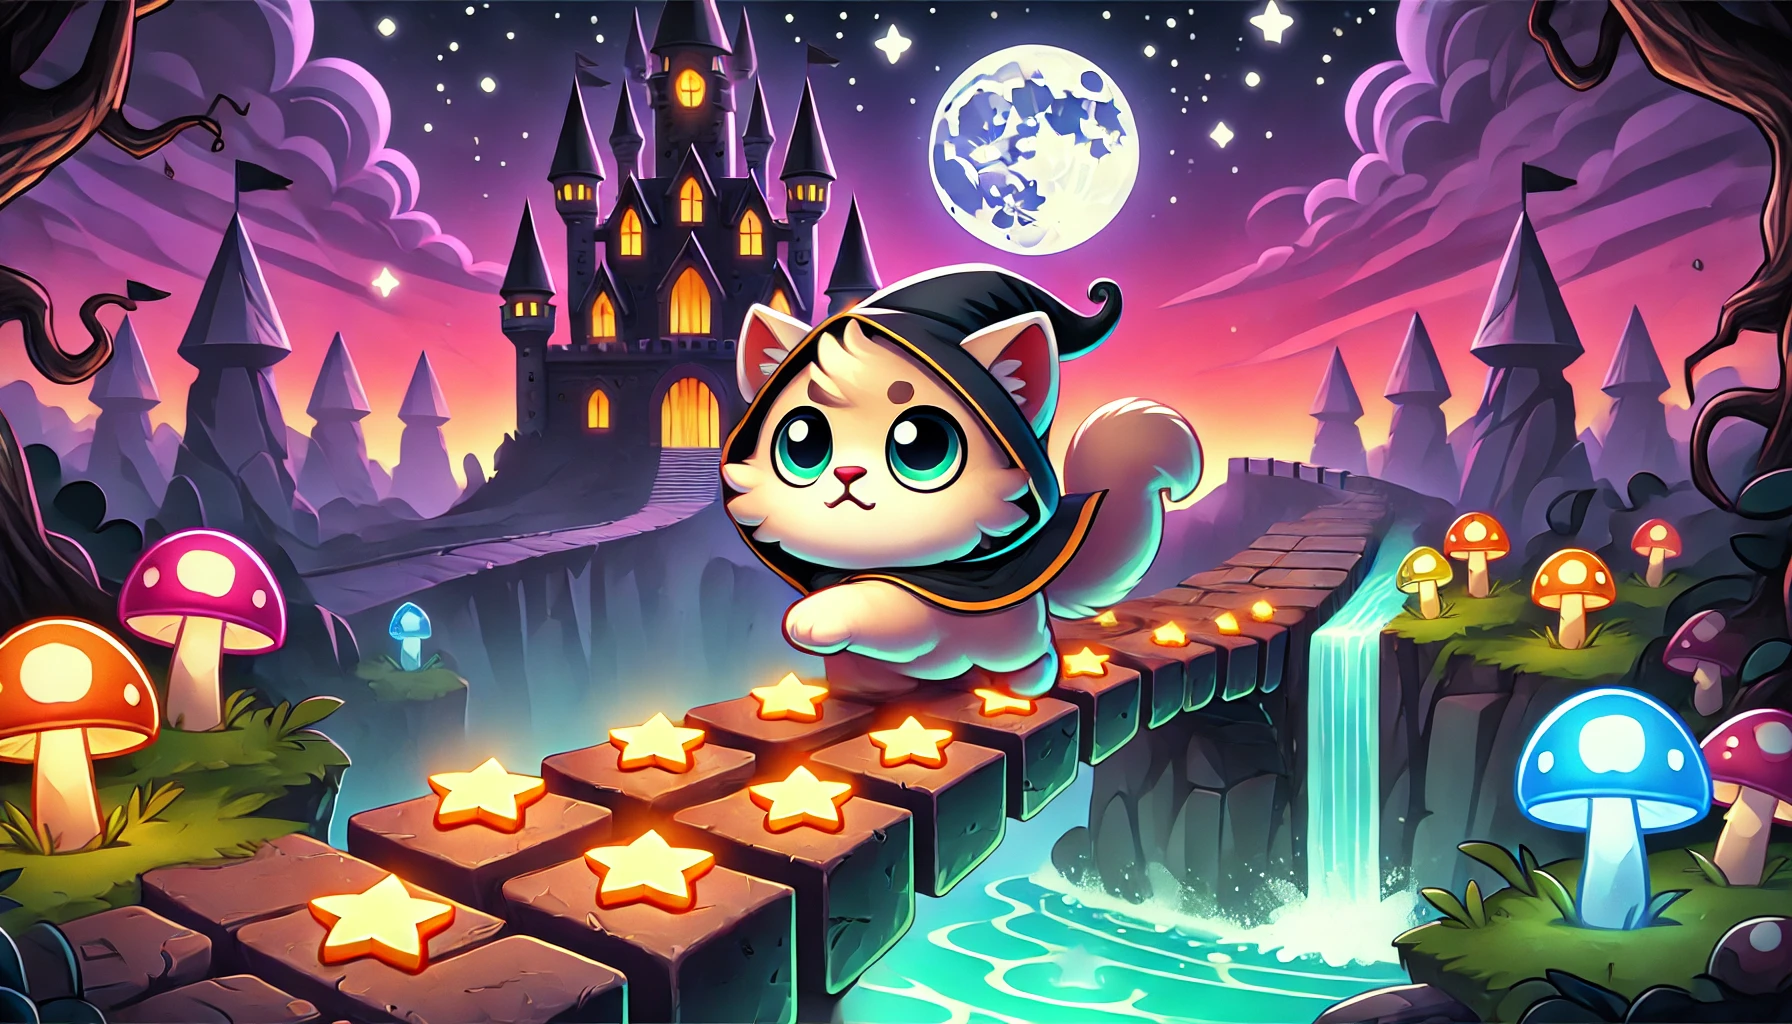

In [1]:
from IPython.display import Image
Image(filename="./images/Project 3.png")

### 문제

고양이 다이나는 사악한 마법사에게 붙잡혀 신비한 성에 갇히게 되었습니다. 이 성에서 빠져나가기 위해서는 별빛이 깃든 마법의 돌다리를 건너야 합니다. 돌다리는 일렬로 연결되어 있으며, 각각의 돌은 고유한 마력을 지니고 있어 이를 이용해 해당 마력만큼의 돌을 건널 수 있습니다. 예를 들어 5번째 돌이 3의 마력을 지니고 있다면, 다이나는 점프를 통해 6번째, 7번째, 8번째 돌 중 하나로 건널 수 있습니다. 문제는 돌에는 마력이 깃들어 있어 이를 밟을 때마다 빛과 소리가 나기 때문에 마법사에게 걸릴 위험이 있다는 것입니다. 그렇기 때문에 다이나는 최소한의 돌다리만 밟아 마지막 칸에 도달해야 합니다.

여러분의 목표는 다이나가 2가지 방법으로 다리를 건너는 최소 점프 횟수를 구할 수 있도록 돕는 것입니다. 첫 번째 방법은 탑다운(top-down) 방식으로, 마지막 칸에 도달하기 위해 현재 위치에서 필요한 최소 점프 수를 재귀적으로 계산하는 것입니다. 이때 이미 계산된 결과는 메모이제이션을 이용해 저장하고, 중복된 계산을 피해야 합니다. 두 번째 방법은 바텀업(bottom-up) 방식으로, 다리의 첫 번째 칸부터 마지막 칸까지 순차적으로 접근하며 현재 칸에서 점프로 도달할 수 있는 각 칸까지의 최소 점프 수를 계산하는 것입니다. 이 경우 테이블의 마지막 칸에 적힌 값이 최종적인 정답이 됩니다.

탈출할 수 있는 시간이 얼마 남지 않았습니다. 다이나가 다리를 무사히 건널 수 있도록 빈칸에 알맞은 코드를 찾아주세요.

### 조건

- 다이나는 첫 번째 칸에서 출발해 정확히 마지막 칸에 도달해야 하며, 마지막 칸의 마력은 0으로 주어집니다.
- 탑다운(top-down) 방식의 해결 과정은 memoization() 함수에 구현합니다.
    - 리스트 `memo`의 i 번째 값은 **i 번째 칸에서 마지막 칸에 도달하기 위해 필요한 최소 점프 수**를 의미합니다.
    - i 번째 칸에서 거리 j만큼 점프할 때, **i 번째 칸에서 필요한 점프 수**는 **(i + j) 번째 칸에서 필요한 점프 수 + 1**입니다.
    - 이를 이용해 모든 칸에서 가능한 점프 범위 내에서 반복하며 재귀적으로 memo를 채워나갑니다.
- 바텀업(bottom-up) 방식의 해결 과정은 tabulation() 함수에 구현합니다.
    - 리스트 `dp`의 i 번째 값은 **0 번째 칸에서 i 번째 칸에 도달하기 위해 필요한 최소 점프 수**를 의미합니다.
    - 0 번째 칸은 항상 출발점이므로 dp[0]은 0으로 초기화됩니다.
    - i 번째 칸에서 거리 j만큼 점프할 때, **(i + j) 번째 칸까지 필요한 점프 수**는 **i 번째 칸까지 필요한 점프 수 + 1**입니다.
    - 이를 이용해 모든 칸에서 가능한 점프 범위 내에서 반복하며 dp 테이블을 채워나갑니다.

In [3]:
# 완성 코드
stones = [2, 4, 1, 1, 3, 0, 3, 1, 5, 0, 4, 2, 1, 0, 1, 3, 0]
n = len(stones)  # 돌다리 칸의 수

memo = [-1] * n  # i 번째 칸에서 마지막 칸에 도달하기 위한 최소 점프 수
dp = [float("inf")] * n  # 0 번째 칸에서 i 번째 칸에 도달하기 위한 최소 점프 수


def memoization(i):
    if i == n - 1:
        return 0
    if memo[i] != -1:
        return memo[i]

    memo[i] = float("inf")
    for j in range(1, stones[i] + 1):
        if i + j < n:
            memo[i] = min(memo[i], memoization(i + j) + 1)

    return memo[i]


def tabulation():
    dp[0] = 0

    for i in range(n):
        for j in range(1, stones[i] + 1):
            if i + j < n:
                dp[i + j] = min(dp[i + j], dp[i] + 1)

    return dp[n - 1]


print("탑다운(top-down) 방식으로 구한 최소 점프 수:", memoization(0))
print("바텀업(bottom-up) 방식으로 구한 최소 점프 수:", tabulation())

탑다운(top-down) 방식으로 구한 최소 점프 수: 8
바텀업(bottom-up) 방식으로 구한 최소 점프 수: 8
